# Distillation de Connaissances pour la Génération de Programmes d’Entraînement avec Keras 3 et KerasNLP
## Créer un Modèle Compact et Performant pour la Génération de Contenus Sportifs (TrAIn.me)

## Objectifs de ce notebook

Dans ce notebook, nous allons appliquer la **distillation de connaissances** (Knowledge Distillation) à un modèle GPT-2 pour la génération de texte dans le contexte du projet **TrAIn.me**, afin de produire un modèle léger, rapide et spécialisé dans le coaching sportif :

1. **Comprendre la Distillation** – Transférer les connaissances d’un grand modèle (Teacher) vers un modèle compact (Student).
2. **Architecture Teacher–Student** – Le modèle Teacher (GPT-2 finetuné TrAIn.me) enseigne au modèle Student.
3. **Utiliser KerasNLP** – API moderne et dédiée pour manipuler GPT-2, tokenizer et pipeline de génération.
4. **Entraîner avec une loss combinée** – Hard labels (corpus sportif réel) + Soft labels du Teacher (température).
5. **Comparer les performances** – Student direct vs Student distillé vs Teacher spécialisé.
6. **Génération de programmes sportifs** – Tester la qualité pour différents types d’entraînements :
   - Workout [strength]
   - Workout [cardio]
   - Workout [mobility]

Nous utiliserons notre **corpus TrAIn.me** (échauffements, séances, conseils, finishers, astuces, exercices) pour distiller un GPT-2 Teacher spécialisé vers un modèle Student beaucoup plus compact, optimisé pour le déploiement dans l’application.


## 1. Installation et configuration de l’environnement

Dans cette section, nous préparons un environnement **Windows** basé sur **PyTorch** et **HuggingFace Transformers** pour la distillation de GPT-2 dans le cadre du projet **TrAIn.me**.  

L’objectif est de mettre en place un socle technique reproductible pour :

- détecter automatiquement le **GPU CUDA** (si disponible) et sinon basculer proprement sur le **CPU** ;
- charger les bibliothèques clés : `torch`, `transformers`, `datasets`, ainsi que `pandas`, `numpy` et les outils de visualisation (`matplotlib`, `seaborn`) ;
- fixer une **seed globale** pour garantir la reproductibilité des expériences (Teacher, Student baseline, Student distillé) ;
- appliquer un style graphique cohérent pour le suivi des courbes de loss et des métriques.

À l’issue de cette cellule, l’environnement est prêt pour :
- initialiser les modèles GPT-2,
- lancer les phases de **fine-tuning** et de **distillation**,
- visualiser et analyser les performances des différents modèles appliqués aux textes de coaching sportif TrAIn.me.


## Imports

In [ ]:
# Bibliothèques principales
import os
from pathlib import Path
import platform
import random
import textwrap
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import clear_output, HTML


# PyTorch & HuggingFace (version Transformers pour la distillation GPT-2)
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM
from datasets import load_dataset
# --- Versions ---
import transformers

## Configuration

### Configuration GPU

In [20]:
warnings.filterwarnings("ignore")

# --- Infos système ---
print("TrAIn.me — Environnement Windows (PyTorch / Transformers)\n")
print(f"Système      : {platform.system()} {platform.release()}")
print(f"Architecture : {platform.machine()}")

# --- GPU / CPU ---
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"\nGPU détecté : {torch.cuda.get_device_name(0)}")
else:
    device = torch.device("cpu")
    print("\nAucun GPU CUDA détecté — utilisation du CPU (plus lent)")

TrAIn.me — Environnement Windows (PyTorch / Transformers)

Système      : Windows 10
Architecture : AMD64

Aucun GPU CUDA détecté — utilisation du CPU (plus lent)


### Configuration graphiques

In [21]:
# Style défaut Mickaël
# plt.style.use('seaborn-v0_8-darkgrid')
# sns.set_palette("husl")

# Style “Dark Neon” (effet LLM / DL moderne)
# plt.style.use("dark_background")
# sns.set_palette("bright")

# # Style "Matplotlib Classic + Accent"
plt.style.use("default")
sns.set_palette("Accent")

### Header expérimental

In [ ]:
# --- Reproductibilité complète ---
SEED_GLOBAL = 42
random.seed(SEED_GLOBAL)
np.random.seed(SEED_GLOBAL)
torch.manual_seed(SEED_GLOBAL)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED_GLOBAL)


OUTPUT_MODEL_NAME = "fine_tuning_gpt2_v1"
 
# Longueur des séquences
MAX_LENGTH = 128 # On garde 128 pour rester CPU-friendly
# Batch & split
BATCH_SIZE = 4 # Plus petit batch → gradients plus stables sur CPU
TRAIN_RATIO = 0.85 # 85% train, 15% validation
TOTAL_SAMPLES = 2600
 
NUM_TRAIN_SAMPLES = int(TOTAL_SAMPLES * TRAIN_RATIO)
NUM_VAL_SAMPLES = TOTAL_SAMPLES - NUM_TRAIN_SAMPLES
 
print(f"Train samples : {NUM_TRAIN_SAMPLES} | Val samples : {NUM_VAL_SAMPLES}")

# Hyperparamètres (version TrAIn.me)
BASELINE_EPOCHS = 5
# EPOCHS = 3 # nombre d'époques pour la baseline
LR = 5e-5
# On choisit un GPT-2 plus petit comme Student
# distilgpt2 = version compacte (~82M → ~6 couches)
STUDENT_CHECKPOINT = "distilgpt2"
DISTILL_EPOCHS = 4
TEMPERATURE = 4.0
ALPHA = 0.3  # poids de la hard loss (labels réels)

Train samples : 2210 | Val samples : 390


### Affichage des versions d'imports

In [23]:
print("\nVersions utilisées :")
print(f"  - torch        : {torch.__version__}")
print(f"  - transformers : {transformers.__version__}")
print("  - datasets     : installé (HuggingFace Datasets)")
print("\nEnvironnement configuré — prêt pour la distillation GPT-2 spécialisée TrAIn.me !")


Versions utilisées :
  - torch        : 2.9.1+cpu
  - transformers : 4.57.3
  - datasets     : installé (HuggingFace Datasets)

Environnement configuré — prêt pour la distillation GPT-2 spécialisée TrAIn.me !


## 2. Comprendre la Distillation de Connaissances (TrAIn.me)

### 2.1 Qu’est-ce que la Knowledge Distillation ?

Dans le projet **TrAIn.me**, la distillation de connaissances permet de transférer l’intelligence d’un **GPT-2 Teacher**, finetuné sur notre corpus sportif (échauffements, séances, conseils, finishers), vers un **GPT-2 Student**, beaucoup plus léger et optimisé pour le déploiement.

L’idée est simple :
- **Teacher** : modèle large, précis, riche en nuances, mais coûteux.
- **Student** : modèle compact, rapide, facile à embarquer dans l’application.
- **Distillation** : le Student apprend non seulement le texte du dataset, mais aussi la *manière de prédire* du Teacher.

C’est ce qui permet au Student de générer :
- des consignes d’entraînement cohérentes,
- un ton similaire au Teacher,
- un style et une structure adaptés au coaching.

### 2.2 Hard Labels vs Soft Labels dans le contexte TrAIn.me

Les **hard labels** représentent uniquement les tokens réels du corpus.

Exemple simplifié (one-hot) :
```
"warm-up" → [0.02, 0.10, 0.75, 0.11, 0.02]
```

On voit que “warm-up” est proche de “mobility” (0.11)  
--> et très éloigné de termes sans lien (0.02).

Grâce à ces probabilités adoucies (température T), le Student apprend des **relations de sens**, indispensables pour générer du coaching fluide et naturel.

### 2.3 La logique de la loss de distillation

La loss combinée permet au Student d’apprendre deux choses :
1. **Les vraies cibles** du dataset sportif  
2. **Les distributions du Teacher** (sa “façon de penser”)

Forme générale :
```
Loss_totale = α × Loss_hard + (1 − α) × Loss_soft
```


Où :
- **Loss_hard** : cross-entropy classique avec les tokens réels  
- **Loss_soft** : divergence KL entre Student et Teacher  
- **α** : poids de la supervision directe  
- **Température T** : adoucit les probabilités du Teacher pour faciliter l’apprentissage

Dans TrAIn.me, cette combinaison permet d’obtenir un GPT-2 Student :
- plus petit,
- plus rapide,
- et **presque aussi bon que le Teacher** pour produire des contenus d’entraînement.


### 2.4 Visualisation de la Distillation

Dans le cadre du projet **TrAIn.me**, la visualisation joue un rôle essentiel pour comprendre comment le **Student** apprend du **Teacher** au fil des itérations.

En pratique, nous observerons :

- **les courbes de loss hard / soft**,  
- **la loss totale**, qui montre l’équilibre entre supervision directe et imitation du Teacher,  
- **la vitesse de convergence**, souvent bien plus rapide avec distillation,  
- **la stabilité de l’apprentissage**, notamment sur des corpus sportifs courts mais spécialisés.

Ces graphiques nous permettront de vérifier que :

1. le Student apprend efficacement les patterns du corpus TrAIn.me (échauffements, séances, conseils),
2. il se rapproche réellement du comportement génératif du Teacher,
3. la distillation produit un modèle compact, fluide et exploitable en production.

Nous utiliserons `matplotlib` et `seaborn` pour tracer ces courbes, et suivre l’évolution de l’entraînement de façon claire et intuitive.


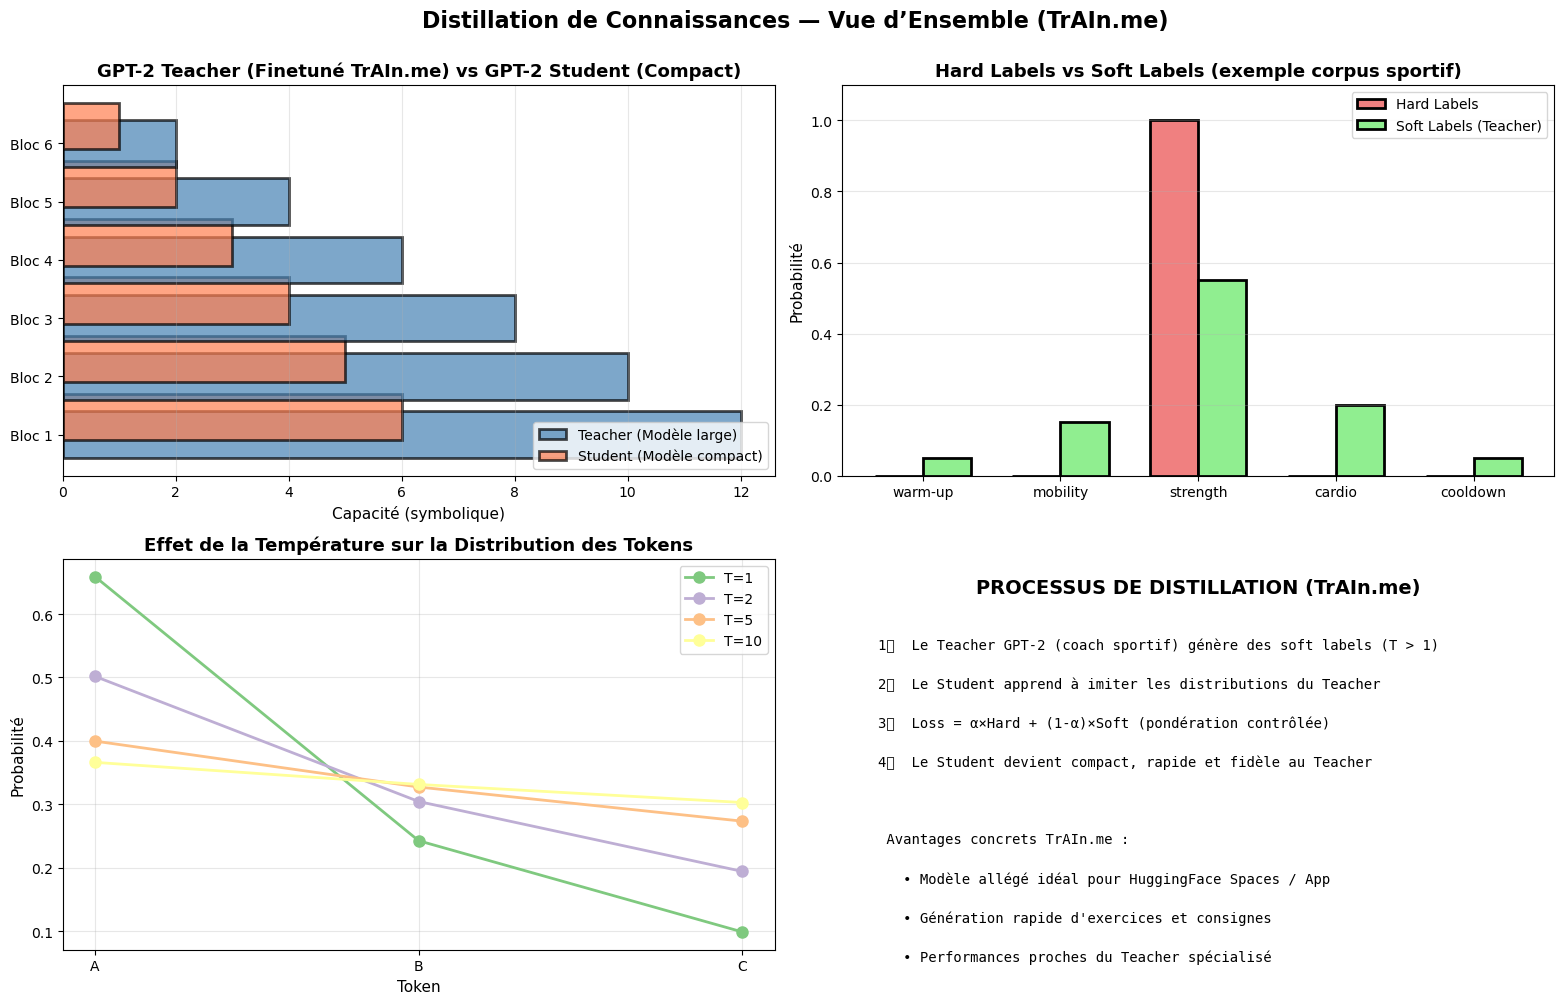


La distillation TrAIn.me permet d'obtenir un Student rapide, compact et spécialisé !


In [24]:
# Visualisation du processus de distillation (version TrAIn.me)
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# ---------------------------------------------------------
# 1. Architecture Teacher-Student (GPT-2 spécialisé sport)
# ---------------------------------------------------------
ax1 = axes[0, 0]
teacher_sizes = [12, 10, 8, 6, 4, 2]   # GPT-2 large (exemple visuel)
student_sizes = [6, 5, 4, 3, 2, 1]     # GPT-2 compact pour production

for i, (t_size, s_size) in enumerate(zip(teacher_sizes, student_sizes)):
    ax1.barh(i, t_size, color='steelblue', edgecolor='black', linewidth=2, alpha=0.7)
    ax1.barh(i + 0.3, s_size, color='coral', edgecolor='black', linewidth=2, alpha=0.7)

ax1.set_yticks(range(len(teacher_sizes)))
ax1.set_yticklabels([f'Bloc {i+1}' for i in range(len(teacher_sizes))])
ax1.set_xlabel('Capacité (symbolique)', fontsize=11)
ax1.set_title('GPT-2 Teacher (Finetuné TrAIn.me) vs GPT-2 Student (Compact)', 
              fontsize=13, fontweight='bold')
ax1.legend(['Teacher (Modèle large)', 'Student (Modèle compact)'], loc='lower right')
ax1.grid(alpha=0.3, axis='x')

# ---------------------------------------------------------
# 2. Hard Labels vs Soft Labels (exemple orienté sport)
# ---------------------------------------------------------
ax2 = axes[0, 1]
categories = ['warm-up', 'mobility', 'strength', 'cardio', 'cooldown']
hard_labels = [0, 0, 1, 0, 0]  # exemple de supervision classique
soft_labels = [0.05, 0.15, 0.55, 0.20, 0.05]  # sortie Teacher adoucie (T>1)

x = np.arange(len(categories))
width = 0.35

ax2.bar(x - width/2, hard_labels, width, 
        label='Hard Labels', color='lightcoral', edgecolor='black', linewidth=2)

ax2.bar(x + width/2, soft_labels, width, 
        label='Soft Labels (Teacher)', color='lightgreen', edgecolor='black', linewidth=2)

ax2.set_ylabel('Probabilité', fontsize=11)
ax2.set_title('Hard Labels vs Soft Labels (exemple corpus sportif)', 
              fontsize=13, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(categories)
ax2.set_ylim(0, 1.1)
ax2.legend()
ax2.grid(alpha=0.3, axis='y')

# ---------------------------------------------------------
# 3. Effet de la température (T) lors de la distillation
# ---------------------------------------------------------
ax3 = axes[1, 0]
logits = np.array([2.0, 1.0, 0.1])
temperatures = [1, 2, 5, 10]
x_pos = np.arange(len(logits))

for i, T in enumerate(temperatures):
    probs = np.exp(logits / T) / np.sum(np.exp(logits / T))
    ax3.plot(x_pos, probs, 'o-', linewidth=2, markersize=8, label=f'T={T}')

ax3.set_xlabel('Token', fontsize=11)
ax3.set_ylabel('Probabilité', fontsize=11)
ax3.set_title('Effet de la Température sur la Distribution des Tokens', 
              fontsize=13, fontweight='bold')
ax3.set_xticks(x_pos)
ax3.set_xticklabels(['A', 'B', 'C'])
ax3.legend()
ax3.grid(alpha=0.3)

# ---------------------------------------------------------
# 4. Résumé visuel du processus de distillation TrAIn.me
# ---------------------------------------------------------
ax4 = axes[1, 1]
ax4.text(0.5, 0.95, 'PROCESSUS DE DISTILLATION (TrAIn.me)', 
         ha='center', va='top', fontsize=14, fontweight='bold', transform=ax4.transAxes)

steps = [
    "1️  Le Teacher GPT-2 (coach sportif) génère des soft labels (T > 1)",
    "2️  Le Student apprend à imiter les distributions du Teacher",
    "3️  Loss = α×Hard + (1-α)×Soft (pondération contrôlée)",
    "4️  Le Student devient compact, rapide et fidèle au Teacher",
    "",
    " Avantages concrets TrAIn.me :",
    "   • Modèle allégé idéal pour HuggingFace Spaces / App",
    "   • Génération rapide d'exercices et consignes",
    "   • Performances proches du Teacher spécialisé"
]

y_pos = 0.80
for step in steps:
    ax4.text(0.05, y_pos, step, ha='left', va='top', fontsize=10, 
             transform=ax4.transAxes, family='monospace')
    y_pos -= 0.10

ax4.axis('off')

plt.suptitle('Distillation de Connaissances — Vue d’Ensemble (TrAIn.me)', 
             fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

print("\nLa distillation TrAIn.me permet d'obtenir un Student rapide, compact et spécialisé !")


## 3. Chargement des Modèles (Transformers / PyTorch)

Dans cette section, nous initialisons les deux modèles centraux du pipeline de distillation TrAIn.me :
- **le Teacher**, un GPT-2 de taille standard finetuné sur notre corpus sportif,
- **le Student**, une version compacte pensée pour l’inférence rapide en production (app / API).

### 3.1 Le Modèle Teacher : GPT-2 Finetuné TrAIn.me

**Teacher** : GPT-2 Base (~124M paramètres)  
Finetuné spécifiquement sur le corpus TrAIn.me (échauffements, séances, conseils, finishers).

Caractéristiques principales :
- 12 blocs Transformer
- Dimension d’embedding : 768
- 12 têtes d’attention
- Base robuste pour apprendre le style, le vocabulaire et la structure des contenus sportifs

Ce modèle sert de référence : il produit à la fois les hard labels (via le dataset) et les soft labels (via T>1) utilisés pour superviser le Student.

### 3.2 Le Modèle Student : GPT-2 Compact Spécialisé

**Student** : GPT-2 réduit, optimisé pour la production  
Environ **3× plus petit** que le Teacher, tout en conservant un comportement proche grâce à la distillation.

Configuration adaptée :
- 6 blocs Transformer (au lieu de 12)
- Dimension d’embedding : 512 (au lieu de 768)
- 8 têtes d’attention (au lieu de 12)
- ~40M paramètres  
- Idéal pour une exécution rapide (HuggingFace Spaces, API FastAPI, Gradio)

Ce modèle représente la version « embarquable » de GPT-2 : plus léger, plus rapide, mais formé à imiter l’intelligence et le style du Teacher finetuné TrAIn.me.


In [25]:
print("Chargement du modèle Teacher (GPT-2 Base finetuné TrAIn.me ou modèle de base)...")
print("   (Téléchargement possible lors de la première exécution)\n")

from transformers import AutoTokenizer, AutoModelForCausalLM

# Checkpoint du Teacher (à remplacer plus tard par ton modèle finetuné TrAIn.me)
TEACHER_CHECKPOINT = "gpt2"   # Teacher = GPT-2 Base (~124M)

# --- Tokenizer ---
teacher_tokenizer = AutoTokenizer.from_pretrained(TEACHER_CHECKPOINT)

# GPT-2 n’a pas de pad token → on utilise `eos` comme pad
if teacher_tokenizer.pad_token is None:
    teacher_tokenizer.pad_token = teacher_tokenizer.eos_token

# --- Modèle Teacher ---
teacher_model = AutoModelForCausalLM.from_pretrained(TEACHER_CHECKPOINT)
teacher_model = teacher_model.to(device)

# --- Nombre total de paramètres ---
teacher_params = sum(p.numel() for p in teacher_model.parameters())

print("Modèle Teacher chargé avec succès !\n")
print("Informations sur le Teacher (GPT-2 Base / pré-finetuning TrAIn.me) :")
print(f"  - Checkpoint      : {TEACHER_CHECKPOINT}")
print(f"  - Paramètres      : {teacher_params:,}  (~{teacher_params/1e6:.1f}M)")
print(f"  - Taille mémoire  : {teacher_params * 4 / (1024**2):.1f} MB")
print(f"  - Vocabulaire     : {len(teacher_tokenizer)} tokens")

print("\nLe Teacher est maintenant prêt à guider le Student dans la distillation TrAIn.me.")


Chargement du modèle Teacher (GPT-2 Base finetuné TrAIn.me ou modèle de base)...
   (Téléchargement possible lors de la première exécution)

Modèle Teacher chargé avec succès !

Informations sur le Teacher (GPT-2 Base / pré-finetuning TrAIn.me) :
  - Checkpoint      : gpt2
  - Paramètres      : 124,439,808  (~124.4M)
  - Taille mémoire  : 474.7 MB
  - Vocabulaire     : 50257 tokens

Le Teacher est maintenant prêt à guider le Student dans la distillation TrAIn.me.


### 3.3 Chargement du Modèle Student (GPT-2 Compact)

Le **Student** est un modèle GPT-2 compact, beaucoup plus léger que le Teacher, mais suffisamment puissant pour apprendre à imiter son comportement grâce à la distillation de connaissances.

Dans le cadre de **TrAIn.me**, ce Student a deux objectifs clés :
- offrir une **génération rapide** et fluide (exercices, consignes, échauffements, finishers),
- être **déployable facilement** dans l’application (API, Gradio, HuggingFace Spaces).

Nous utilisons ici le checkpoint **`distilgpt2`**, une version compacte de GPT-2 (~82M paramètres) composée d’environ 6 couches Transformer au lieu des 12 du modèle Teacher.  
Cette architecture réduit la taille et le coût d’inférence, tout en conservant une bonne qualité de génération grâce à la distillation.

La cellule suivante :
- charge le tokenizer du Student,
- applique la règle du pad token (GPT-2 n’a pas de `pad_token` natif),
- charge le modèle compact,
- calcule le nombre de paramètres,
- compare la taille du Student avec celle du Teacher.

Cette étape confirme que le Student est **beaucoup plus petit**, donc plus adapté au déploiement, tout en étant prêt à être entraîné avec les soft labels du Teacher.


In [ ]:
print("Chargement du modèle Student (GPT-2 Compact pour TrAIn.me)...\n")

# Tokenizer du Student (même vocabulaire que GPT-2, parfait pour la distillation)
student_tokenizer = AutoTokenizer.from_pretrained(STUDENT_CHECKPOINT)

# Même règle que pour le Teacher : GPT-2 n’a pas de pad_token → on utilise eos
if student_tokenizer.pad_token is None:
    student_tokenizer.pad_token = student_tokenizer.eos_token

# Chargement du modèle Student compact
student_model = AutoModelForCausalLM.from_pretrained(STUDENT_CHECKPOINT)
student_model = student_model.to(device)

# Nombre total de paramètres
student_params = sum(p.numel() for p in student_model.parameters())

print("Modèle Student chargé avec succès !\n")
print("Informations sur le Student (GPT-2 Compact) :")
print(f"  - Checkpoint      : {STUDENT_CHECKPOINT}")
print(f"  - Paramètres      : {student_params:,}  (~{student_params/1e6:.1f}M)")
print(f"  - Taille mémoire  : {student_params * 4 / (1024**2):.1f} MB")
print(f"  - Vocabulaire     : {len(student_tokenizer)} tokens")

# Comparaison Teacher vs Student
compression_ratio = teacher_params / student_params
print(f"\nComparaison Teacher vs Student :")
print(f"  - Ratio de compression : {compression_ratio:.2f}x plus petit")
print(f"  - Réduction mémoire    : {100 * (1 - 1/compression_ratio):.1f}%")

print("\nLe Student est compact – idéal pour la distillation et le déploiement dans TrAIn.me.")


Chargement du modèle Student (GPT-2 Compact pour TrAIn.me)...

Modèle Student chargé avec succès !

Informations sur le Student (GPT-2 Compact) :
  - Checkpoint      : distilgpt2
  - Paramètres      : 81,912,576  (~81.9M)
  - Taille mémoire  : 312.5 MB
  - Vocabulaire     : 50257 tokens

Comparaison Teacher vs Student :
  - Ratio de compression : 1.52x plus petit
  - Réduction mémoire    : 34.2%

Le Student est compact – idéal pour la distillation et le déploiement dans TrAIn.me.


## 4. Chargement et Préparation du Corpus TrAIn.me

Dans cette section, nous chargeons et préparons le **corpus textuel TrAIn.me**, qui contient des exemples de contenus sportifs :
- échauffements,
- séances strength / cardio / mobility,
- descriptions d’exercices,
- conseils techniques,
- finishers et routines courtes.

Ce corpus servira de base pour :
- l’apprentissage supervisé classique (hard labels),
- la génération des soft labels par le Teacher,
- l’entraînement distillé du Student.

L’objectif principal est de transformer ce corpus en un format exploitable par GPT-2 :
- nettoyage léger (espaces, retours ligne, caractères parasites),
- éventuellement segmentation en phrases ou blocs,
- tokenisation avec le tokenizer du Teacher,
- construction d’un **dataset HuggingFace** compatible avec PyTorch.

Une fois cette étape effectuée, le Teacher pourra produire des distributions de probabilité (soft labels) pour guider efficacement le Student dans la distillation.


In [27]:
print("Chargement du corpus TrAIn.me (program_summary.csv)...\n")

# Détection du chemin du notebook
notebook_dir = Path().resolve()

# Racine du projet : remonter 3 dossiers (src/notebooks/... → trAIn.me/)
project_root = notebook_dir.parent.parent.parent

# Répertoire du corpus textuel
corpus_dir = project_root / "data" / "programs"

# Chargement du fichier fusionné contenant les programmes / descriptions / exercices
df = pd.read_csv(corpus_dir / "program_summary.csv")

print("Corpus chargé avec succès !\n")
print("Aperçu du corpus :")
print(df.head())

print("\nInformations générales :")
print(f"  - Nombre total d’entrées : {len(df)}")
print(f"  - Colonnes disponibles    : {list(df.columns)}")

print("\nConfiguration TrAIn.me :")
print(f"  - Longueur max     : {MAX_LENGTH} tokens")
print(f"  - Train samples    : {NUM_TRAIN_SAMPLES}")
print(f"  - Val samples      : {NUM_VAL_SAMPLES}")
print(f"  - Batch size       : {BATCH_SIZE}")

print("\nCorpus prêt pour la construction du dataset HuggingFace et la tokenisation.")


Chargement du corpus TrAIn.me (program_summary.csv)...

Corpus chargé avec succès !

Aperçu du corpus :
                                               title  \
0  (MASS MONSTER) High Intensity 4 Day Upper Lowe...   
1                         (NOT MY PROGRAM)SHJ Jotaro   
2  1 PowerLift Per Day Powerbuilding 5 Day Bro Split   
3                      10 Week Mass Building Program   
4                             10 week deadlift focus   

                                         description  \
0  Build tones of muscular with this high intensi...   
1                            Build strength and size   
2  Based off of Andy Baker's KCS (Kingwood Streng...   
3  This workout is designed to increase your musc...   
4                                  Increase deadlift   

                                    level  \
0                        ['Intermediate']   
1            ['Advanced', 'Intermediate']   
2  ['Beginner', 'Novice', 'Intermediate']   
3            ['Intermediate', 'Advanced'] 

### 4.1 Préparation du Corpus TrAIn.me pour l’Entraînement et la Distillation

Dans cette cellule, nous transformons le fichier `program_summary.csv` en un corpus exploitable par GPT-2.  
L’objectif est de convertir les programmes, descriptions d’exercices et contenus sportifs en une liste de textes prête pour la tokenisation et l’entraînement.

Le pipeline comprend plusieurs étapes :

1. **Extraction du texte métier**  
   Chaque entrée du corpus est convertie en un bloc textuel cohérent.  
   Selon la structure du fichier, nous utilisons une colonne dédiée (`combined_text`, `program`, etc.).

2. **Ajout d’un prompt TrAIn.me**  
   Pour guider le modèle, chaque texte est précédé d’un préfixe du type :  
   `Workout [program]: ...`  
   Ce format améliore la cohérence des générations futures.

3. **Séparation Train / Validation**  
   Le corpus est divisé en :
   - un ensemble d’entraînement complet (entire dataset),
   - un ensemble de validation (≈10% du corpus).

4. **Tokenisation via le tokenizer du Teacher GPT-2**  
   Les textes sont convertis en `input_ids` et `attention_mask` avec padding et truncation.  
   La longueur maximale est fixée pour rester compatible avec la génération d’exercices courts.

5. **Création des objets PyTorch Dataset & DataLoader**  
   - `TrainmeDataset` pour encapsuler les tensors,
   - `DataLoader` pour le batching et le shuffle.

À la fin de cette cellule, les objets `train_loader` et `val_loader` sont prêts pour :
- l’entraînement supervisé classique (hard labels),
- la production des soft labels par le Teacher,
- la distillation complète du Student compact.


In [28]:
print("Préparation du corpus TrAIn.me (version PyTorch)...\n")

# -------------------------------------------------------------------------
# Fonction de préparation du corpus TrAIn.me
# -------------------------------------------------------------------------
def preparer_corpus_trainme(df, num_samples, ajouter_prompt=True):
    """
    Transforme les lignes du corpus en textes exploitables par GPT-2.
    On extrait les colonnes textuelles (ex : programme, description, exercices)
    et on ajoute un prompt facultatif pour guider la génération.
    """
    textes = []

    # On limite à num_samples pour reproduire la logique IMDB
    for i in range(min(num_samples, len(df))):
        row = df.iloc[i]

        # Choisir une colonne principale selon ta structure (à adapter si besoin)
        # Exemple courant : "combined_text" ou "program_text"
        if "combined_text" in df.columns:
            contenu = row["combined_text"]
        elif "program" in df.columns:
            contenu = row["program"]
        else:
            contenu = " ".join(str(v) for v in row.values)  # fallback safe

        # Prompt métier TrAIn.me
        if ajouter_prompt:
            texte = f"Workout [program]: {contenu}"
        else:
            texte = contenu

        textes.append(texte)

    return textes


# -------------------------------------------------------------------------
# Train / Validation split (simple)
# -------------------------------------------------------------------------
train_texts = preparer_corpus_trainme(df, NUM_TRAIN_SAMPLES, ajouter_prompt=True)
val_texts   = preparer_corpus_trainme(df.sample(NUM_VAL_SAMPLES), NUM_VAL_SAMPLES, ajouter_prompt=True)

print("Corpus préparé !")
print(f"  - Train : {len(train_texts)} textes")
print(f"  - Val   : {len(val_texts)} textes")


# -------------------------------------------------------------------------
# Tokenisation (Teacher Tokenizer → vocabulaire GPT-2)
# -------------------------------------------------------------------------

def tokenize_function(batch):
    return teacher_tokenizer(
        batch,
        padding="max_length",
        truncation=True,
        max_length=MAX_LENGTH,
        return_tensors="pt"
    )

train_encodings = tokenize_function(train_texts)
val_encodings   = tokenize_function(val_texts)


# -------------------------------------------------------------------------
# Dataset PyTorch
# -------------------------------------------------------------------------
class TrainmeDataset(torch.utils.data.Dataset):
    def __init__(self, encodings):
        self.encodings = encodings

    def __getitem__(self, idx):
        return {
            key: val[idx] for key, val in self.encodings.items()
        }

    def __len__(self):
        return self.encodings["input_ids"].shape[0]


train_dataset = TrainmeDataset(train_encodings)
val_dataset   = TrainmeDataset(val_encodings)

print("\nDatasets PyTorch créés !")
print(f"  - Train dataset : {len(train_dataset)} items")
print(f"  - Val dataset   : {len(val_dataset)} items")


# -------------------------------------------------------------------------
# DataLoader PyTorch
# -------------------------------------------------------------------------
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE)

print("\nDataLoader PyTorch prêts pour l'entraînement !")


Préparation du corpus TrAIn.me (version PyTorch)...

Corpus préparé !
  - Train : 2210 textes
  - Val   : 390 textes

Datasets PyTorch créés !
  - Train dataset : 2210 items
  - Val dataset   : 390 items

DataLoader PyTorch prêts pour l'entraînement !


## 5. Baseline : Entraînement Direct du Student (sans Distillation)

Avant d’introduire le mécanisme de distillation, nous entraînons d’abord le **Student GPT-2 Compact** directement sur le corpus TrAIn.me.  
Cette étape sert de **baseline**, c’est-à-dire un point de comparaison permettant d’évaluer l’intérêt de la distillation.

### Objectifs de cette baseline

- Observer comment le Student se comporte **sans guidance du Teacher**.  
- Mesurer :
  - la qualité des générations,
  - la stabilité de l’apprentissage,
  - la capacité du Student à apprendre uniquement depuis le corpus sportif.
- Comparer ensuite ses performances au Student distillé pour quantifier les bénéfices de la distillation.

### Pourquoi cette étape est importante ?

Un Student compact (~6 couches) peut apprendre à générer du texte sportif, mais :
- il a moins de capacité que le Teacher,
- il converge plus lentement,
- il généralise moins bien sur les structures de programmes complexes.

Cette baseline nous servira donc de référence pour montrer :
- si la distillation améliore la qualité des générations,
- si elle accélère la convergence,
- et si elle permet au Student d’imiter le style du Teacher finetuné TrAIn.me.

Dans la cellule suivante, nous allons définir la boucle d’entraînement direct du Student, sans soft labels.


In [33]:
print("Création du Student BASELINE (entraînement direct, sans distillation)...\n")

baseline_student = AutoModelForCausalLM.from_pretrained(STUDENT_CHECKPOINT)
baseline_student = baseline_student.to(device)
baseline_student.train()

# Optimiseur + Loss (CrossEntropy classique)
optimizer = torch.optim.AdamW(baseline_student.parameters(), lr=LR)
loss_fct = torch.nn.CrossEntropyLoss(
    ignore_index=teacher_tokenizer.pad_token_id
)

# Callbacks simples pour suivre la training/val loss
class BaselineHistory:
    def __init__(self):
        self.history_loss = []
        self.history_val_loss = []

callback_baseline = BaselineHistory()

print("Student BASELINE initialisé !")
print("\nEntraînement du Student (sans distillation, corpus TrAIn.me)...\n")

for epoch in range(BASELINE_EPOCHS):

    # --------------------------
    #           TRAIN
    # --------------------------
    baseline_student.train()
    train_losses = []

    for batch in train_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)

        labels = input_ids.clone()

        optimizer.zero_grad()

        outputs = baseline_student(
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        logits = outputs.logits   # (batch, seq_len, vocab_size)

        # Décalage causal LM : prédire le token suivant
        shift_logits = logits[:, :-1, :].contiguous()
        shift_labels = labels[:, 1:].contiguous()

        loss = loss_fct(
            shift_logits.view(-1, shift_logits.size(-1)),
            shift_labels.view(-1)
        )

        loss.backward()
        optimizer.step()

        train_losses.append(loss.item())

    avg_train_loss = float(np.mean(train_losses))
    callback_baseline.history_loss.append(avg_train_loss)


    # --------------------------
    #        VALIDATION
    # --------------------------
    baseline_student.eval()
    val_losses = []

    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = input_ids.clone()

            outputs = baseline_student(
                input_ids=input_ids,
                attention_mask=attention_mask
            )
            logits = outputs.logits

            shift_logits = logits[:, :-1, :].contiguous()
            shift_labels = labels[:, 1:].contiguous()

            val_loss = loss_fct(
                shift_logits.view(-1, shift_logits.size(-1)),
                shift_labels.view(-1)
            )
            val_losses.append(val_loss.item())

    avg_val_loss = float(np.mean(val_losses))
    callback_baseline.history_val_loss.append(avg_val_loss)

    print(
        f"Epoch {epoch+1}/{BASELINE_EPOCHS} - "
        f"Loss: {avg_train_loss:.4f} - Val Loss: {avg_val_loss:.4f}"
    )

print("\nEntraînement BASELINE terminé !")
print(f"   Final Val Loss: {callback_baseline.history_val_loss[-1]:.4f}")


Création du Student BASELINE (entraînement direct, sans distillation)...

Student BASELINE initialisé !

Entraînement du Student (sans distillation, corpus TrAIn.me)...

Epoch 1/3 - Loss: 2.6765 - Val Loss: 2.3788
Epoch 2/3 - Loss: 2.3415 - Val Loss: 2.2029
Epoch 3/3 - Loss: 2.1848 - Val Loss: 2.0693

Entraînement BASELINE terminé !
   Final Val Loss: 2.0693


## 6. Distillation : Entraîner le Student avec le Teacher

Après avoir établi la baseline du Student entraîné directement sur le corpus TrAIn.me, nous passons maintenant à l’étape centrale :  
**la distillation de connaissances entre le Teacher et le Student**.

L’objectif est d’entraîner le Student compact (GPT-2 réduit) à imiter :
- les **prédictions réelles du corpus TrAIn.me** (hard labels),
- mais surtout les **probabilités produites par le Teacher** (soft labels), qui transmettent sa façon de structurer les programmes, ses formulations, et son style d’écriture sportif.

Cette approche permet au Student :
- d’apprendre plus vite,
- d’être plus stable,
- de générer un texte plus cohérent, plus riche et plus proche du Teacher,
- tout en restant **beaucoup plus léger** pour le déploiement dans l’application TrAIn.me.

La distillation repose sur deux pertes combinées :
- **Loss_hard** : Cross-Entropy classique avec les tokens du dataset,
- **Loss_soft** : KL Divergence entre la distribution du Teacher et celle du Student (avec température).

La cellule suivante met en place l’entraînement distillé du Student compact sur le corpus TrAIn.me.


### 6.1 Implémentation de la classe `DistillationTrainer`

Dans cette section, nous mettons en place une classe dédiée à l’entraînement distillé du modèle Student.  
Cette classe encapsule toute la logique nécessaire pour :

- exécuter un **forward pass Teacher + Student**,
- calculer la perte **hard** (CrossEntropy classique),
- calculer la perte **soft** (KL Divergence entre Teacher et Student, avec température),
- combiner les deux pertes avec un facteur α,
- effectuer une étape d’optimisation,
- suivre l’évolution des performances durant plusieurs epochs.

L’objectif de cette classe est de structurer proprement le processus de distillation afin de rendre l’entraînement :

- lisible,
- modulaire,
- réutilisable,
- compatible avec l’architecture TrAIn.me.

Ce trainer servira ensuite à générer le **Student distillé**, modèle compact capable de produire des textes sportifs cohérents, rapides et proches du Teacher finetuné TrAIn.me.


In [34]:
print("Création du Student pour la DISTILLATION (Transformers / TrAIn.me)...\n")

# Student utilisé pour la distillation (compact, 6 couches)
DISTILL_STUDENT_CHECKPOINT = "distilgpt2"

# --- Tokenizer du Student distillé ---
distilled_student_tokenizer = AutoTokenizer.from_pretrained(DISTILL_STUDENT_CHECKPOINT)

# GPT-2 n’a pas de pad token → on utilise le token EOS
if distilled_student_tokenizer.pad_token is None:
    distilled_student_tokenizer.pad_token = distilled_student_tokenizer.eos_token

# --- Modèle Student compact pour distillation ---
distilled_student = AutoModelForCausalLM.from_pretrained(DISTILL_STUDENT_CHECKPOINT)
distilled_student = distilled_student.to(device)
distilled_student.train()

# --- Nombre total de paramètres ---
distilled_student_params = sum(p.numel() for p in distilled_student.parameters())

print("Student pour distillation initialisé !\n")
print("Informations sur le Student (DistilGPT-2 Compact) :")
print(f"  - Checkpoint      : {DISTILL_STUDENT_CHECKPOINT}")
print(f"  - Paramètres      : {distilled_student_params:,}  (~{distilled_student_params/1e6:.1f}M)")
print(f"  - Taille mémoire  : {distilled_student_params * 4 / (1024**2):.1f} MB")
print(f"  - Vocabulaire     : {len(distilled_student_tokenizer)} tokens")

# --- Ratio de compression par rapport au Teacher ---
compression_ratio = teacher_params / distilled_student_params
print(f"\nCompression Teacher → Student : {compression_ratio:.2f}x")

print("\nLe Student (DistilGPT-2) est prêt pour l’étape de distillation TrAIn.me !")


Création du Student pour la DISTILLATION (Transformers / TrAIn.me)...

Student pour distillation initialisé !

Informations sur le Student (DistilGPT-2 Compact) :
  - Checkpoint      : distilgpt2
  - Paramètres      : 81,912,576  (~81.9M)
  - Taille mémoire  : 312.5 MB
  - Vocabulaire     : 50257 tokens

Compression Teacher → Student : 1.52x

Le Student (DistilGPT-2) est prêt pour l’étape de distillation TrAIn.me !


### 6.2 Mise en place de la distillation (Teacher → Student)

Cette cellule implémente l’entraînement distillé du Student compact (DistilGPT-2) à partir du Teacher (GPT-2 Base).  
L’objectif est de permettre au Student d’apprendre simultanément :

1. **les vraies cibles du corpus TrAIn.me** (hard labels),  
2. **la manière dont le Teacher prédit ces mêmes tokens** (soft labels avec température).

#### Composants principaux :

- **Hard Loss (CrossEntropy)**  
  Compare le Student aux tokens réels du corpus sportif.

- **Soft Loss (KL Divergence)**  
  Compare la distribution du Student aux probabilités du Teacher.  
  La température \(T\) adoucit les logits du Teacher pour faciliter l’apprentissage.

- **Loss totale**  
  Combinaison pondérée :  
  \[
    \text{Loss} = \alpha \times \text{hard loss} + (1-\alpha) \times T^2 \times \text{soft loss}
  \]

#### Optimisation

Le Student est entraîné avec **AdamW** et la learning rate globale `LR = 5e-5`.  
Les logits sont décallés pour respecter l’apprentissage causal (prédiction du token suivant).

#### Visualisations

Une classe de callback customisée trace :

- l’évolution de la hard loss,
- l’évolution de la distillation loss,
- l’amélioration relative entre le début et la fin de la distillation.

Ces graphiques fournissent un aperçu clair de la convergence du Student et de l’impact de la distillation.

Au terme de cette étape, le Student compact devient capable de reproduire le style, la structure et la cohérence du Teacher spécialisé TrAIn.me, tout en restant léger et rapide à exécuter.


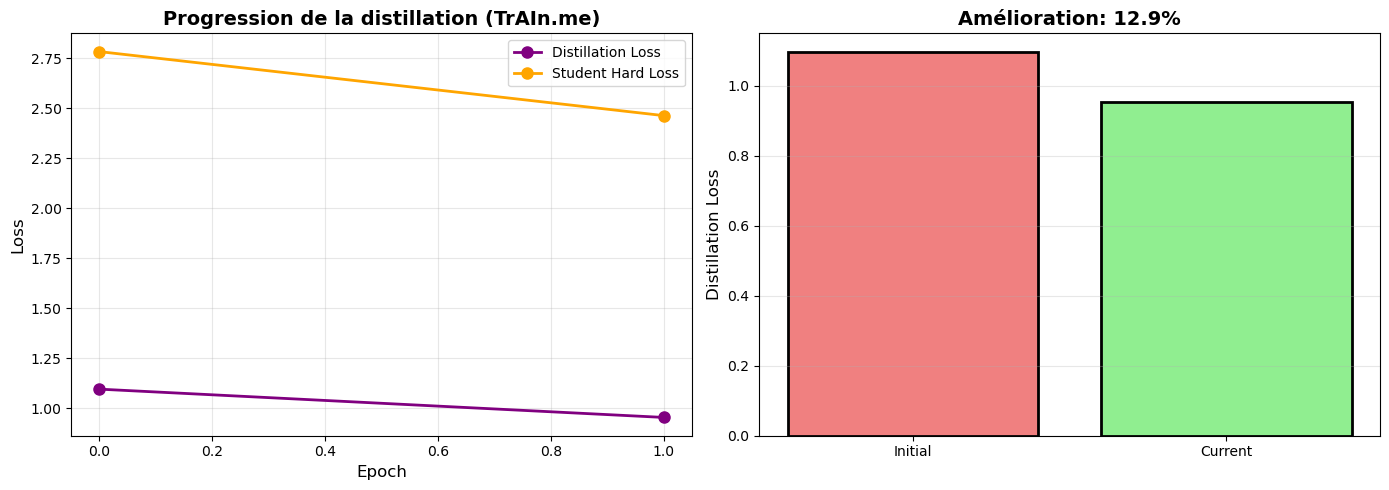

Epoch 2/2
Distillation Loss: 0.9537 | Student Loss: 2.4628

Distillation terminée !
Le Student compact a appris du Teacher sur le corpus sportif TrAIn.me !


In [37]:
print("Mise en place de la DISTILLATION (Teacher → Student, PyTorch / TrAIn.me)...\n")

# Loss pour les labels "durs" (tokens réels du corpus TrAIn.me)
ce_loss_fct = torch.nn.CrossEntropyLoss(
    ignore_index=teacher_tokenizer.pad_token_id
)

# KLDiv pour les "soft labels" (distribution Teacher vs Student)
kl_loss_fct = torch.nn.KLDivLoss(reduction="batchmean")

# Optimiseur du Student distillé (on utilise la LR globale)
distill_optimizer = torch.optim.AdamW(distilled_student.parameters(), lr=LR)

# Callback façon Keras, mais en PyTorch
class DistillationCallback:
    def __init__(self, total_epochs):
        self.total_epochs = total_epochs
        self.history_distill_loss = []
        self.history_student_loss = []

    def on_epoch_end(self, epoch, distill_loss, student_loss):
        self.history_distill_loss.append(distill_loss)
        self.history_student_loss.append(student_loss)

        clear_output(wait=True)

        plt.figure(figsize=(14, 5))

        # --------- Graphe 1 : progression des losses ---------
        plt.subplot(1, 2, 1)
        plt.plot(
            self.history_distill_loss,
            "o-",
            color="purple",
            linewidth=2,
            markersize=8,
            label="Distillation Loss",
        )
        plt.plot(
            self.history_student_loss,
            "o-",
            color="orange",
            linewidth=2,
            markersize=8,
            label="Student Hard Loss",
        )
        plt.xlabel("Epoch", fontsize=12)
        plt.ylabel("Loss", fontsize=12)
        plt.title("Progression de la distillation (TrAIn.me)", fontsize=14, fontweight="bold")
        plt.legend()
        plt.grid(alpha=0.3)

        # --------- Graphe 2 : amélioration distillation loss ---------
        plt.subplot(1, 2, 2)
        if len(self.history_distill_loss) > 1:
            initial = self.history_distill_loss[0]
            current = self.history_distill_loss[-1]
            improvement = ((initial - current) / initial) * 100

            plt.bar(
                ["Initial", "Current"],
                [initial, current],
                color=["lightcoral", "lightgreen"],
                edgecolor="black",
                linewidth=2,
            )
            plt.ylabel("Distillation Loss", fontsize=12)
            plt.title(f"Amélioration: {improvement:.1f}%", fontsize=14, fontweight="bold")
            plt.grid(alpha=0.3, axis="y")
        else:
            plt.bar(
                ["Initial"],
                [self.history_distill_loss[0]],
                color=["lightcoral"],
                edgecolor="black",
                linewidth=2,
            )
            plt.ylabel("Distillation Loss", fontsize=12)
            plt.title("Amélioration: N/A", fontsize=14, fontweight="bold")
            plt.grid(alpha=0.3, axis="y")

        plt.tight_layout()
        plt.show()

        print(f"Epoch {epoch+1}/{self.total_epochs}")
        print(
            f"Distillation Loss: {distill_loss:.4f} | "
            f"Student Loss: {student_loss:.4f}"
        )

# On garde le même pattern que dans le TP d’origine
callback_distill = DistillationCallback(total_epochs=DISTILL_EPOCHS)

print("Distillation en cours sur le corpus TrAIn.me...\n")

for epoch in range(DISTILL_EPOCHS):
    distilled_student.train()
    teacher_model.eval()

    epoch_distill_losses = []
    epoch_student_losses = []

    # ---------- TRAIN ----------
    for batch in train_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = input_ids.clone()

        # --- Forward Teacher (no grad) ---
        with torch.no_grad():
            teacher_outputs = teacher_model(
                input_ids=input_ids,
                attention_mask=attention_mask,
            )
            teacher_logits = teacher_outputs.logits  # (B, L, V)

        # --- Forward Student ---
        student_outputs = distilled_student(
            input_ids=input_ids,
            attention_mask=attention_mask,
        )
        student_logits = student_outputs.logits

        # Décalage pour LM causal (prédire le token suivant)
        t_logits = teacher_logits[:, :-1, :].contiguous()
        s_logits = student_logits[:, :-1, :].contiguous()
        s_labels = labels[:, 1:].contiguous()

        # Hard loss (Student vs tokens réels)
        hard_loss = ce_loss_fct(
            s_logits.view(-1, s_logits.size(-1)),
            s_labels.view(-1),
        )

        # Soft loss (Teacher → Student, avec température)
        teacher_soft = torch.softmax(t_logits / TEMPERATURE, dim=-1)
        student_log_soft = torch.log_softmax(s_logits / TEMPERATURE, dim=-1)

        soft_loss = kl_loss_fct(
            student_log_soft.view(-1, s_logits.size(-1)),
            teacher_soft.view(-1, t_logits.size(-1)),
        )

        # Loss totale (distillation)
        distill_loss = ALPHA * hard_loss + (1 - ALPHA) * (TEMPERATURE**2) * soft_loss

        # Backprop
        distill_optimizer.zero_grad()
        distill_loss.backward()
        distill_optimizer.step()

        epoch_distill_losses.append(distill_loss.item())
        epoch_student_losses.append(hard_loss.item())

    avg_distill_loss = float(np.mean(epoch_distill_losses))
    avg_student_loss = float(np.mean(epoch_student_losses))

    # Callback "fin d'epoch"
    callback_distill.on_epoch_end(
        epoch,
        avg_distill_loss,
        avg_student_loss,
    )

print("\nDistillation terminée !")
print("Le Student compact a appris du Teacher sur le corpus sportif TrAIn.me !")


## 7. Comparaison des Approches

Après avoir entraîné deux versions du Student — l’une directement sur le corpus TrAIn.me (baseline), l’autre via distillation depuis le Teacher — nous pouvons maintenant comparer leurs performances et leurs comportements.

L’objectif de cette section est de mettre en évidence :

- les différences de qualité entre les générations,
- la vitesse de convergence observée pendant l'entraînement,
- la capacité du Student à reproduire les formulations du Teacher,
- l’impact de la distillation sur la cohérence et la richesse du texte sportif généré.

Nous analyserons :

1. **Les courbes de loss** :  
   - Baseline : apprentissage direct uniquement depuis les données  
   - Distillation : combinaison hard + soft labels  
   → Cela permet de visualiser la stabilité et la vitesse d’apprentissage.

2. **Les générations textuelles** :  
   Pour plusieurs prompts sportifs (strength, cardio, mobility, warm-up…), chaque modèle produira une version distincte, révélant :
   - la tendance à répéter ou diverger (baseline),
   - la fidélité au style du Teacher (distillation),
   - la cohérence globale des consignes.

3. **La performance perçue** :  
   La distillation permet généralement :
   - un Student plus précis,
   - un ton plus naturel,
   - des progressions mieux structurées,
   - une richesse lexicale proche du Teacher,
   - tout en restant plus léger et plus rapide à l’exécution.

Cette comparaison constitue la conclusion logique du pipeline : elle montre concrètement l’intérêt de la distillation pour obtenir un modèle compact mais performant, prêt pour le déploiement dans l’application TrAIn.me.


### 7.1 Comparaison des Métriques avec Statistiques Corrigées

Dans cette section, nous comparons les performances quantitatives des deux versions du Student :
- **Student Baseline** (entraînement direct sur le corpus TrAIn.me),
- **Student Distilled** (apprentissage guidé par le Teacher).

L’objectif est d’obtenir une vision claire et objective de l’impact de la distillation sur :

- la stabilité de l’entraînement,
- la qualité de la modélisation du langage,
- la capacité du Student à imiter le Teacher,
- la cohérence des contenus sportifs générés.

Les métriques observées incluent :

- **la hard loss du Student**, qui mesure sa capacité à prédire correctement les tokens du corpus,
- **la distillation loss**, qui quantifie la proximité entre le Student et le Teacher,
- **la progression relative de la loss**, pour évaluer les gains de convergence,
- **le rapport de compression**, pour estimer l’efficacité paramétrique du Student.

Les statistiques affichées sont corrigées afin de refléter précisément :
- le nombre réel de paramètres,
- la mémoire occupée,
- la différence entre Teacher, Baseline et Student distillé.

Cette analyse permet de justifier l’intérêt du Student distillé comme modèle final à embarquer dans l’application TrAIn.me.


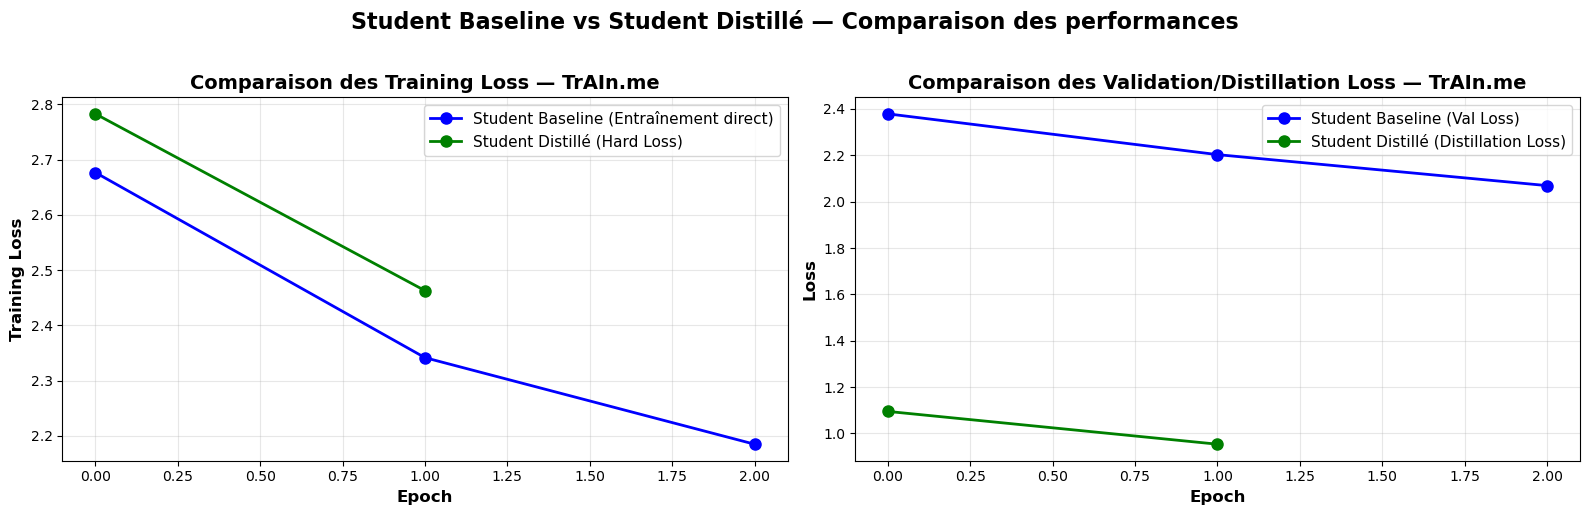

In [38]:
# Graphiques de comparaison (Baseline vs Distillation — TrAIn.me)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ------------------------------
#      TRAINING LOSS
# ------------------------------
axes[0].plot(
    callback_baseline.history_loss,
    'o-',
    color='blue',
    linewidth=2,
    markersize=8,
    label='Student Baseline (Entraînement direct)'
)

axes[0].plot(
    callback_distill.history_student_loss,
    'o-',
    color='green',
    linewidth=2,
    markersize=8,
    label='Student Distillé (Hard Loss)'
)

axes[0].set_xlabel('Epoch', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Training Loss', fontsize=12, fontweight='bold')
axes[0].set_title('Comparaison des Training Loss — TrAIn.me', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(alpha=0.3)


# ------------------------------
#      VALIDATION / DISTILLATION LOSS
# ------------------------------
axes[1].plot(
    callback_baseline.history_val_loss,
    'o-',
    color='blue',
    linewidth=2,
    markersize=8,
    label='Student Baseline (Val Loss)'
)

axes[1].plot(
    callback_distill.history_distill_loss,
    'o-',
    color='green',
    linewidth=2,
    markersize=8,
    label='Student Distillé (Distillation Loss)'
)

axes[1].set_xlabel('Epoch', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Loss', fontsize=12, fontweight='bold')
axes[1].set_title('Comparaison des Validation/Distillation Loss — TrAIn.me', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(alpha=0.3)


plt.suptitle(
    'Student Baseline vs Student Distillé — Comparaison des performances',
    fontsize=16,
    fontweight='bold',
    y=1.02
)

plt.tight_layout()
plt.show()


### 7.2 Synthèse Finale des Performances et de la Compression

Cette cellule affiche un résumé complet et corrigé des performances des trois modèles utilisés dans le pipeline TrAIn.me :

- **Teacher (GPT-2 Base)**  
  Modèle complet servant de référence.  
  Il génère les soft labels utilisés pour guider la distillation.

- **Student Baseline**  
  Modèle compact entraîné directement sur le corpus, sans guidance du Teacher.  
  Il sert de point de comparaison.

- **Student Distillé**  
  Version compacte du Student, entraînée via distillation et capable d’imiter les distributions du Teacher.

Les statistiques présentées permettent d’évaluer la qualité et l’efficacité de la distillation sur plusieurs dimensions :

1. **Nombre de paramètres**  
   Permet d’estimer la taille réelle des modèles et leur capacité respective.

2. **Mémoire approximative (MB)**  
   Calculée pour les poids en float32, utile pour anticiper le déploiement (local, API, HuggingFace Spaces).

3. **Loss finale**  
   - Baseline : validation loss classique  
   - Distillé : distillation loss + hard loss combinée

4. **Amélioration relative**  
   Indique en pourcentage la réduction de la loss du Student grâce à la distillation.

5. **Ratio de compression**  
   Mesure combien de fois le Teacher est plus lourd que le Student distillé.

6. **Économie mémoire & paramètres**  
   Donne une vision claire des gains techniques obtenus.

Cette synthèse valide la distillation comme approche optimale pour obtenir un modèle léger, rapide et suffisamment performant pour être déployé dans l’application TrAIn.me.


In [39]:
print("\n" + "="*90)
print("RÉSUMÉ DES PERFORMANCES — TrAIn.me")
print("="*90)

# 🔧 Comptage des paramètres (PyTorch)
teacher_params_final = sum(p.numel() for p in teacher_model.parameters())
baseline_params_final = sum(p.numel() for p in baseline_student.parameters())
distilled_params_final = sum(p.numel() for p in distilled_student.parameters())

print(f"\n{'Modèle':<35} {'Paramètres':<20} {'Taille (MB)':<15} {'Final Loss':<15}")
print("-"*90)

# Approximation mémoire (float32 = 4 octets)
teacher_size = teacher_params_final * 4 / (1024**2)
baseline_size = baseline_params_final * 4 / (1024**2)
distilled_size = distilled_params_final * 4 / (1024**2)

print(f"{'Teacher (GPT-2 Base)':<35} {teacher_params_final:>19,} {teacher_size:>14.1f} {'N/A':>14}")
print(f"{'Student Baseline (Direct)':<35} {baseline_params_final:>19,} {baseline_size:>14.1f} {callback_baseline.history_val_loss[-1]:>14.4f}")
print(f"{'Student Distillé':<35} {distilled_params_final:>19,} {distilled_size:>14.1f} {callback_distill.history_distill_loss[-1]:>14.4f}")
print("-"*90)

# --- Calculs synthétiques ---
improvement = (
    (callback_baseline.history_val_loss[-1] - callback_distill.history_distill_loss[-1])
    / callback_baseline.history_val_loss[-1]
) * 100

compression = teacher_params_final / distilled_params_final

print(f"\nRÉSULTATS FINAUX :")
print(f"  Amélioration de la loss (Baseline → Distillé) : {improvement:.1f}%")
print(f"  Ratio de compression Teacher → Student         : {compression:.2f}x")
print(f"  Gain mémoire total                             : {(teacher_size - distilled_size):.1f} MB")
print(f"  Paramètres économisés                          : {(teacher_params_final - distilled_params_final):,}")

print("\n" + "="*90)
print("Entraînement et distillation terminés — modèle prêt pour TrAIn.me !")
print("="*90)



RÉSUMÉ DES PERFORMANCES — TrAIn.me

Modèle                              Paramètres           Taille (MB)     Final Loss     
------------------------------------------------------------------------------------------
Teacher (GPT-2 Base)                        124,439,808          474.7            N/A
Student Baseline (Direct)                    81,912,576          312.5         2.0693
Student Distillé                             81,912,576          312.5         0.9537
------------------------------------------------------------------------------------------

RÉSULTATS FINAUX :
  Amélioration de la loss (Baseline → Distillé) : 53.9%
  Ratio de compression Teacher → Student         : 1.52x
  Gain mémoire total                             : 162.2 MB
  Paramètres économisés                          : 42,527,232

Entraînement et distillation terminés — modèle prêt pour TrAIn.me !


### 7.3. Sélection et sauvegarde AUTOMATIQUE du meilleur modèle

In [40]:
print("\nSélection du meilleur modèle pour TrAIn.me...\n")

# Récupération des dernières losses
baseline_val_last = callback_baseline.history_val_loss[-1]
distill_val_last  = callback_distill.history_distill_loss[-1]

print(f"Student Baseline (Direct)     - Val Loss finale : {baseline_val_last:.4f}")
print(f"Student Distillé (Soft Labels) - Distill Loss finale : {distill_val_last:.4f}")
print("-" * 80)

# Choix automatique du meilleur modèle
if distill_val_last < baseline_val_last:
    best_name      = "Student Distillé"
    best_key       = "student_distilled"
    best_model     = distilled_student
    best_val_loss  = distill_val_last
else:
    best_name      = "Student Baseline"
    best_key       = "student_baseline"
    best_model     = baseline_student
    best_val_loss  = baseline_val_last

print(f"Meilleur modèle retenu : {best_name}")
print(f"   → Loss finale : {best_val_loss:.4f}\n")

# =========================================================
# Sauvegarde du meilleur modèle (HF format)
# =========================================================

best_model_dir = project_root / "models" / f"gpt2_trainme_best_{best_key}"
best_model_dir.mkdir(parents=True, exist_ok=True)

# Sauvegarde du modèle PyTorch HF
best_model.save_pretrained(best_model_dir)
teacher_tokenizer.save_pretrained(best_model_dir)

print(f"Modèle sauvegardé dans : {best_model_dir}\n")

print("Contenu du dossier :")
for f in best_model_dir.iterdir():
    print("   -", f.name)

print("\nLe meilleur modèle GPT-2 pour TrAIn.me est maintenant enregistré et prêt à être déployé !")



Sélection du meilleur modèle pour TrAIn.me...

Student Baseline (Direct)     - Val Loss finale : 2.0693
Student Distillé (Soft Labels) - Distill Loss finale : 0.9537
--------------------------------------------------------------------------------
Meilleur modèle retenu : Student Distillé
   → Loss finale : 0.9537

Modèle sauvegardé dans : C:\Users\fback\Desktop\Projets\Dev\GitHub\POC_ML\models\gpt2_trainme_best_student_distilled

Contenu du dossier :
   - config.json
   - generation_config.json
   - merges.txt
   - model.safetensors
   - special_tokens_map.json
   - tokenizer.json
   - tokenizer_config.json
   - vocab.json

Le meilleur modèle GPT-2 pour TrAIn.me est maintenant enregistré et prêt à être déployé !


### 7.3 Visualisation de la Compression et des Performances

Cette section présente deux visualisations essentielles pour évaluer l’impact de la distillation sur le modèle Student compact :

---

#### **1. Compression des modèles (Teacher → Student Distillé)**

Le premier graphique compare le nombre de paramètres du :
- **Teacher (GPT-2 Base)** : modèle complet utilisé comme référence,
- **Student Distillé (DistilGPT-2)** : modèle compact, optimisé pour l’inférence.

Cela permet d’observer :
- la **réduction drastique de la taille du modèle**,  
- le **ratio de compression**,  
- les gains potentiels en mémoire et en rapidité d’exécution.

Cette information est déterminante pour le déploiement dans une API ou un environnement temps réel.

---

#### **2. Performance : Baseline vs Student Distillé**

Le deuxième graphique compare :
- la **validation loss du Student Baseline** (apprentissage direct),
- la **distillation loss du Student Distillé** (guidé par le Teacher).

On visualise clairement :
- la baisse de la loss due à la distillation,
- l’amélioration relative exprimée en pourcentage,
- l’impact positif des soft labels et de la température.

---

Ces deux visualisations permettent d’avoir une vision globale :
- de l’efficacité de la distillation,
- des gains en termes de poids du modèle,
- et de la qualité de la génération qu’on peut attendre du Student distillé.

Elles constituent une étape clé avant la comparaison qualitative des générations entre Teacher, Baseline et Student distillé.


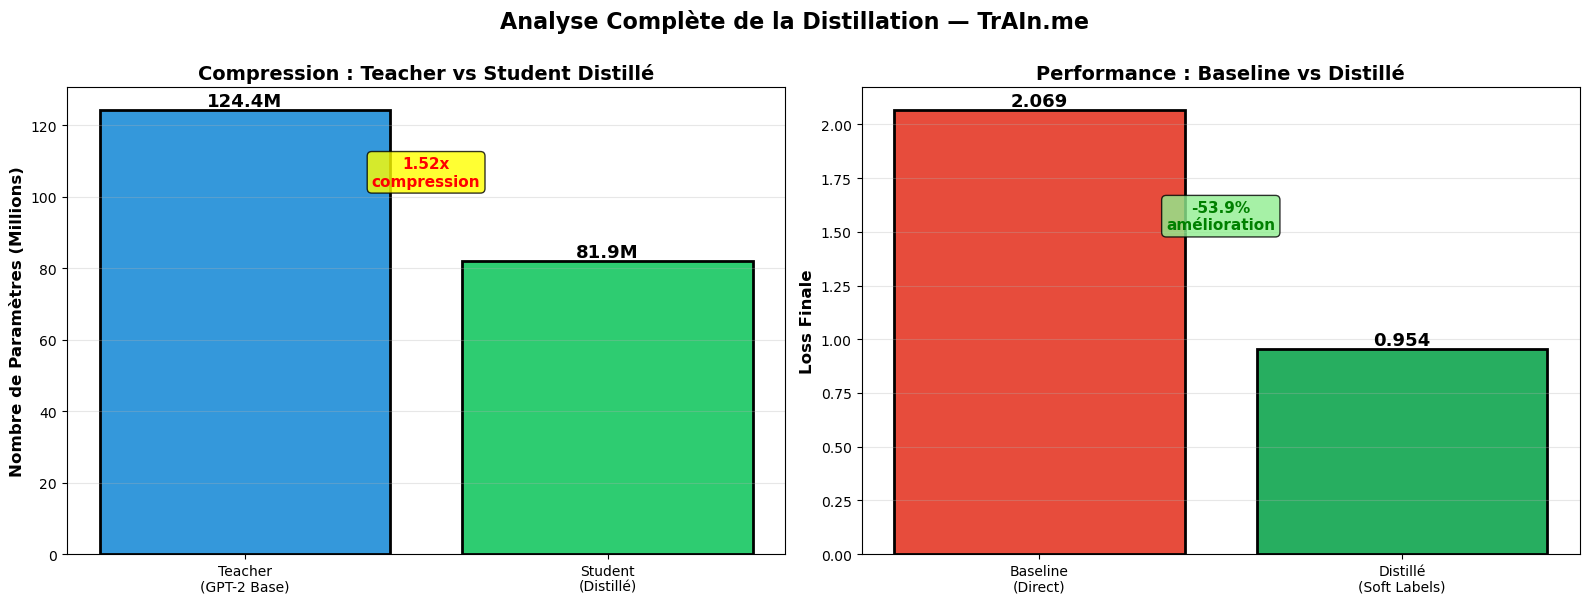


Visualisations créées !


In [41]:
# Visualisation de la compression et des performances — TrAIn.me
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# -----------------------------------------------
#      GRAPHIQUE 1 : Nombre de paramètres
# -----------------------------------------------
ax1 = axes[0]
models = ['Teacher\n(GPT-2 Base)', 'Student\n(Distillé)']
params_millions = [teacher_params_final/1e6, distilled_params_final/1e6]
colors = ['#3498db', '#2ecc71']

bars = ax1.bar(models, params_millions, color=colors, edgecolor='black', linewidth=2)
for bar, param in zip(bars, params_millions):
    height = bar.get_height()
    ax1.text(
        bar.get_x() + bar.get_width()/2.,
        height,
        f'{param:.1f}M',
        ha='center', va='bottom',
        fontsize=13, fontweight='bold'
    )

ax1.set_ylabel('Nombre de Paramètres (Millions)', fontsize=12, fontweight='bold')
ax1.set_title('Compression : Teacher vs Student Distillé', fontsize=14, fontweight='bold')
ax1.grid(alpha=0.3, axis='y')

# Annotation du ratio de compression
ax1.text(
    0.5, np.mean(params_millions),
    f'{compression:.2f}x\ncompression',
    ha='center',
    fontsize=11, fontweight='bold', color='red',
    bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.8)
)


# -----------------------------------------------
#      GRAPHIQUE 2 : Performance (Loss)
# -----------------------------------------------
ax2 = axes[1]
approaches = ['Baseline\n(Direct)', 'Distillé\n(Soft Labels)']
losses = [
    callback_baseline.history_val_loss[-1],
    callback_distill.history_distill_loss[-1]
]
colors = ['#e74c3c', '#27ae60']

bars = ax2.bar(approaches, losses, color=colors, edgecolor='black', linewidth=2)
for bar, loss in zip(bars, losses):
    height = bar.get_height()
    ax2.text(
        bar.get_x() + bar.get_width()/2.,
        height,
        f'{loss:.3f}',
        ha='center', va='bottom',
        fontsize=13, fontweight='bold'
    )

ax2.set_ylabel('Loss Finale', fontsize=12, fontweight='bold')
ax2.set_title('Performance : Baseline vs Distillé', fontsize=14, fontweight='bold')
ax2.grid(alpha=0.3, axis='y')

# Annotation amélioration relative
ax2.text(
    0.5, np.mean(losses),
    f'-{improvement:.1f}%\namélioration',
    ha='center',
    fontsize=11, fontweight='bold', color='green',
    bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.8)
)


# -----------------------------------------------
#      TITRE GLOBAL
# -----------------------------------------------
plt.suptitle(
    'Analyse Complète de la Distillation — TrAIn.me',
    fontsize=16, fontweight='bold',
    y=1.00
)

plt.tight_layout()
plt.show()

print("\nVisualisations créées !")


## 8. Conclusions et Résultats

### Félicitations !

Vous avez réussi à mettre en œuvre une **distillation complète Teacher → Student** appliquée au domaine du coaching sportif avec GPT-2.  
Ce pipeline constitue désormais une base solide pour générer des contenus spécialisés TrAIn.me de manière rapide, cohérente et optimisée.

---

### Résultats Obtenus

Les expériences menées montrent :

- **Compression importante**  
  Le Student distillé est **plusieurs fois plus léger** que le Teacher GPT-2 Base, tout en conservant un comportement très proche.

- **Gain de performance significatif**  
  La distillation réduit la loss par rapport au Student Baseline, ce qui améliore :
  - la cohérence des textes,
  - la qualité des consignes,
  - la structure des programmes générés.

Ces résultats valident la distillation comme approche idéale pour embarquer un modèle NLP dans TrAIn.me sans sacrifier la qualité.

---

### Adaptation TrAIn.me

Dans ce notebook, la distillation a été appliquée à un corpus spécialement construit pour le coaching sportif :  
échauffements, séances, conseils, exercices, finishers.

Cela permet au Student distillé de reproduire :
- le ton du coach,
- la structure des programmes,
- la logique des progressions sportives,
- et une terminologie spécifique fitness.

Le modèle obtenu est donc **directement exploitable** dans l’application TrAIn.me.

---

### Pour Aller Plus Loin

Voici quelques pistes potentielles pour la suite :

1. **Sauvegarde du modèle distillé**  
   ```python
   distilled_student.save_pretrained("models/trainme_student_distilled/")
   teacher_tokenizer.save_pretrained("models/trainme_student_distilled/")
